**Analytics in Business Capstone Project**

# Report: Heat Smart Orkney

**Group B**

For our client Kaluza, we quantify Orkney wind curtailment from turbine telemetry, estimate how much residential
demand response (DR) can absorb at different enrolment levels, and translate the opportunity
into a monetisation and break-even view for Kaluza's Heat Smart Orkney (HSO) programme.

> **Research question:** <br>
> How much Orkney wind curtailment can be mitigated through residential demand response, and what economic value does this unlock for households and the Heat Smart Orkney programme?
<br>
<br>
> **Subsidary questions:**
>- (Q1) Annual curtailed energy across Orkney
>- (Q2) Curtailment reduction potential as a function of DR penetration
>- (Q3) Household participation required to deliver that DR capacity
<br>
<br>


# Summary

This report investigates whether residential demand response through Kaluza’s Heat Smart Orkney (HSO) platform can meaningfully reduce wind curtailment on the Orkney Islands, where renewable generation is constrained by limited export capacity to mainland Great Britain. After cleaning and analysing operational wind and demand data, the study validated a non-linear turbine power curve to estimate unconstrained generation and quantify annual curtailed energy. The analysis estimates that Orkney curtails approximately **76.86 GWh of wind energy per year**, confirming that curtailment is a significant technical and economic issue. A flexible residential heating demand model was then developed to evaluate how much of this curtailed energy could be recovered through smart electric heating. Under a full-enrolment scenario, the HSO framework avoids approximately **267 MWh/year**, corresponding to only **0.35%** of total curtailed energy, while a 25% penetration scenario would require roughly **2,596 participating homes**. Although the results support the technical feasibility of residential flexibility, they also show that residential demand response alone cannot materially reduce system-wide curtailment levels. The business analysis further indicates that Kaluza’s direct revenues remain limited under current assumptions (approximately **£3,007/year at full penetration**) unless supported by subsidies, grid incentives, or partnerships with wind operators. Overall, the report concludes that the strategic value of Heat Smart Orkney lies less in eliminating curtailment at scale and more in demonstrating the operational and commercial viability of flexible demand orchestration within future smart-grid systems.


# Introduction

The transition toward low-carbon electricity systems requires not only large-scale renewable generation, but also sufficient flexibility to absorb intermittent production. On the Orkney Islands, wind generation capacity has expanded rapidly due to excellent wind resources, yet the local electricity network remains constrained by limited export capacity to mainland Great Britain. In particular, a **40 MW subsea cable** caps the amount of electricity that can be transmitted off the islands at any given time. During periods of strong wind and relatively low local demand, total generation can therefore exceed the combined capacity of local consumption and exports.

To preserve network stability under these conditions, the distribution network operator reduces the operating setpoints of wind turbines, forcing generators to produce less electricity than would otherwise be available from the wind resource. This process, known as **curtailment**, leads to renewable energy being effectively wasted: curtailed electricity cannot be sold on wholesale markets and does not contribute to carbon displacement. Curtailment therefore represents both an economic loss for generators and a missed opportunity for decarbonisation.

Kaluza’s **Heat Smart Orkney (HSO)** project addresses this challenge through a demand response strategy based on flexible residential electric heating. Rather than reducing wind generation during constrained periods, HSO seeks to dynamically increase electricity demand by activating enrolled household heating systems whenever excess renewable generation is available. By shifting electricity consumption toward periods of surplus wind production, the project aims to convert otherwise-curtailed renewable energy into useful thermal demand.

This report investigates the scale, temporal dynamics, and potential recoverability of curtailed wind energy in Orkney, with the objective of assessing the business value of residential demand response in this context. The analysis is guided by the following hypotheses:

| ID     | Hypothesis                                                                                                                   | Validation Approach                                |
| ------ | ---------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------- |
| **P1** | Annual fleet curtailment is material (on the order of 10+ GWh)                                                               | Energy balance analysis                            |
| **P2** | Curtailment is temporally concentrated during windy, low-demand periods                                                      | Exploratory data analysis and time-series analysis |
| **P3** | A bounded but meaningful share of curtailed energy can be recovered through residential demand response                      | Flexible demand saturation modelling               |
| **P4** | Wind turbine power output follows a non-linear saturating relationship with wind speed, capped near rated capacity (≈900 kW) | Empirical power curve validation                   |

To answer these questions, the report first performs data cleaning and exploratory analysis of wind generation, curtailment signals, and operational behaviour. A validated turbine power curve is then constructed to estimate unconstrained production and quantify curtailment levels. Building on this foundation, a flexible residential heating demand model is developed and matched against periods of excess renewable generation in order to estimate the proportion of curtailed energy that could realistically be absorbed by demand response. Finally, the operational findings are translated into a business and energy-system perspective, highlighting the economic and environmental implications of smart flexible demand in constrained renewable networks.


# Technologies and techniques 

Every headline number in this report flows from the constants below. For each parameter we state
**what it means in the model**, and **where it comes from** (client data, technical brief, FAQ,
or a consultant judgement flagged as such). Post-2017 statistics are not used, consistent with the
2017 scenario.

| Parameter | Value (central) | What it means | Source / rationale |
|-----------|-----------------|---------------|-------------------|
| `HEADLINE_YEAR` | 2017 | Calendar year for turbine curtailment totals and demand matching. | Aligns with `Residential_demand.csv` (2017 only). Turbine telemetry is filtered to 2017 even though the file spans 2015–2018 (`energy_brief.pdf`). |
| `NAMEPLATE_KW` | 900 | Maximum rated output of the exemplar turbine in the dataset. | Stated in case brief and `Turbine_telemetry.csv` (setpoint tops out at 900 kW). |
| `NAMEPLATE_FRAC` | 0.99 | Setpoint below this fraction of nameplate ⇒ **curtailed regime** (network cap active). | Modelling convention from `energy_brief.pdf` (setpoint as curtailment signal). Threshold is slightly below 900 kW to avoid numerical edge cases. |
| `N_TURBINES` | 500 | Scales single-turbine results to an Orkney-wide fleet. | `energy_brief.pdf`: >500 turbines on Orkney as of Sept 2018; FAQ invites 500 or a 2017-cited count — we use **500** as central scenario. Sensitivity: 400–600 in Appendix. |
| `FLEET_CORRELATION` | 1.0 | Multiplier if turbines are not statistically independent (0.85–1.0 stress test). | FAQ: scale one average turbine; correlation = 1 assumes identical machines and weather exposure. |
| `STORM_MEAN_MS` / `STORM_PEAK_MS` | 25 / 30 | 10-min mean wind >25 m/s or gust >30 m/s ⇒ **storm shutdown** (excluded from curve fit and curtailment sums). | `HSO FAQ.txt` (storm control per turbine datasheet behaviour). |
| `CUT_IN_MS` | 3.0 | Minimum wind for generation; used to classify **downtime** (zero power with wind above cut-in). | Approximate from EDA on telemetry; not critical per FAQ. |
| `N_HOUSEHOLDS_ORKNEY` | 10,385 | Denominator for DR **penetration** and scaler from sample mean kW to island demand. | `HSO FAQ.txt` (approximate Orkney household count). Distinct from `N_households` in the demand file (~5,400 sample). |
| `DEMAND_ANOMALY_MONTHS` | Sep, Oct | Months excluded from **EDA plots** only (sample size spikes to ~30k). | `HSO FAQ.txt` (likely data-quality anomaly). Flexible-load and Q2 matching still use **full-year** demand timestamps. |
| `F_FLEX` | 0.40 | Share of **variable** residential demand that smart heating can shift for DR. | Consultant assumption within FAQ range (best/worst case via household count); central 40% with sensitivity 25–55%. `energy_brief.pdf` discusses shiftable heating load. |
| `AVAILABILITY` | 0.70 | Fraction of enrolled homes **online and dispatchable** when curtailment occurs. | Consultant assumption (devices offline, opt-out, comfort limits). Sensitivity 50–90%. |
| `WHOLESALE_GBP_MWH` | 45 | £ value per MWh of avoided curtailment (wholesale proxy). | **2017-era** GB wholesale order-of-magnitude (£35–55/MWh band). Not a single published Orkney price — documented as planning range. |
| `KALUZA_VALUE_SHARE` | 0.333 | Kaluza’s share of gross avoided-curtailment value after consumer/generator split. | Illustrative revenue-share for business case (`HSO FAQ.txt`: negotiate splits with wind farms and consumers). |
| `HUB_GBP` | 100 | Retrofit control hub cost **per radiator** controlled. | `energy_brief.pdf` / FAQ (~£100 per device). |
| `RADIATORS_PER_HOME` | 2 | Number of radiators/heating zones controlled per home. | Consultant assumption (typical storage-heater home); affects capex. |
| `HEATER_GBP` | 300 | Quantum heater hardware cost per home (2017 money). | FAQ: ~£600 in 2018 list price, **halved** for 2017 if no historical series. |
| `SUBSIDY_LEVELS` | 25–100% | Share of upfront capex paid by programme/government in break-even scenarios. | `HSO FAQ.txt` (explore 25%, 50%, 75%, 100% subsidies). |
| `EXPORT_CAP_MW` (Appendix) | 40 | Max export to mainland GB used in optional system-balance check. | `energy_brief.pdf` (40 MW cable). Not used in headline Q1. |

**Data sources (fixed inputs, not tunable assumptions):**

- `data/Turbine_telemetry.csv` — one 900 kW turbine, ~1 min resolution (`Formatting Rules` / FAQ: scale to fleet).
- `data/Residential_demand.csv` — Kaluza proxy aggregate, 30 min, `Demand_mean_kw` per sample household.


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

from IPython.display import display
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import PchipInterpolator
from scipy import stats

# Plot style (readable for marking / export)
plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

DATA_DIR = Path("data")
HEADLINE_YEAR = 2017

# --- Physical & fleet ---
NAMEPLATE_KW = 900
NAMEPLATE_FRAC = 0.99
N_TURBINES = 500
FLEET_CORRELATION = 1.0
STORM_MEAN_MS = 25.0
STORM_PEAK_MS = 30.0
CUT_IN_MS = 3.0  # approximate; refined from data in EDA

# --- Orkney households ---
N_HOUSEHOLDS_ORKNEY = 10_385
DEMAND_ANOMALY_MONTHS = [9, 10]  # Sep–Oct 2017 sample-size spike (FAQ)

# --- DR flexibility ---
F_FLEX = 0.40
AVAILABILITY = 0.70
F_FLEX_LOW, F_FLEX_HIGH = 0.25, 0.55
AVAIL_LOW, AVAIL_HIGH = 0.50, 0.90

# --- Economics (2017 planning scenario) ---
WHOLESALE_GBP_MWH = 45.0
WHOLESALE_LOW, WHOLESALE_HIGH = 35.0, 55.0
KALUZA_VALUE_SHARE = 0.333
HUB_GBP = 100.0
RADIATORS_PER_HOME = 2
HEATER_GBP = 300.0
SUBSIDY_LEVELS = [0.25, 0.50, 0.75, 1.00]
PENETRATION_GRID = [0, 100, 250, 500, 1000, 2000, 3000, 5000, 7500, 10000, N_HOUSEHOLDS_ORKNEY]
DR_PENETRATION_TARGETS = [0.10, 0.25, 0.50]  # share of Orkney households enrolled
EXPORT_CAP_MW = 40.0  # Appendix system-balance check only (energy_brief.pdf)

# --- Value-pool splits (illustrative four-actor models, must sum to 1.0) ---
SHARE_HOUSEHOLD = 0.40   # discounted energy / bill savings
SHARE_WIND = 0.25        # royalty to generators
SHARE_KALUZA = 0.25      # platform + install margin (aligned with KALUZA_VALUE_SHARE order of magnitude)
SHARE_GRID = 0.10        # balancing / constraint payment
HOUSEHOLD_DISCOUNT_GBP_MWH = 20.0  # £ benefit per MWh shifted to curtailed-wind slots
WIND_ROYALTY_ADMIN_GBP_YR = 5_000   # minimum annual fee wind farm pays Kaluza to participate
GRID_VALUE_GBP_MWH = 8.0             # implied £/MWh for constraint relief (illustrative)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

assumptions = pd.DataFrame([
    {"parameter": "headline_year", "value": HEADLINE_YEAR,
     "meaning": "Analysis year for annual curtailment and DR matching",
     "source": "Residential_demand.csv coverage; energy_brief.pdf"},
    {"parameter": "nameplate_kw", "value": NAMEPLATE_KW,
     "meaning": "Rated max power of exemplar turbine",
     "source": "Case dataset + energy_brief.pdf"},
    {"parameter": "nameplate_frac", "value": NAMEPLATE_FRAC,
     "meaning": "Setpoint threshold defining curtailed regime",
     "source": "energy_brief.pdf (setpoint semantics)"},
    {"parameter": "n_turbines", "value": N_TURBINES,
     "meaning": "Fleet multiplier for Orkney-wide Q1 scaling",
     "source": "energy_brief.pdf (>500 turbines); HSO FAQ (suggest 500)"},
    {"parameter": "fleet_correlation", "value": FLEET_CORRELATION,
     "meaning": "Correlation adjustment on fleet scale",
     "source": "HSO FAQ (scale average turbine); sensitivity in Appendix"},
    {"parameter": "storm_mean_ms", "value": STORM_MEAN_MS,
     "meaning": "10-min mean wind limit for storm exclusion",
     "source": "HSO FAQ.txt"},
    {"parameter": "storm_peak_ms", "value": STORM_PEAK_MS,
     "meaning": "Peak gust limit for storm exclusion",
     "source": "HSO FAQ.txt"},
    {"parameter": "cut_in_ms", "value": CUT_IN_MS,
     "meaning": "Cut-in wind for downtime classification",
     "source": "EDA on telemetry (approximate)"},
    {"parameter": "n_households_orkney", "value": N_HOUSEHOLDS_ORKNEY,
     "meaning": "Orkney households for penetration % and demand scaling",
     "source": "HSO FAQ.txt (~10,385)"},
    {"parameter": "demand_anomaly_months", "value": str(DEMAND_ANOMALY_MONTHS),
     "meaning": "Months flagged in EDA (sample N_households spike)",
     "source": "HSO FAQ.txt (Sep–Oct 2017 anomaly)"},
    {"parameter": "f_flex", "value": F_FLEX,
     "meaning": "Fraction of variable demand dispatchable by DR heating",
     "source": "Consultant assumption; FAQ best/worst framing"},
    {"parameter": "availability", "value": AVAILABILITY,
     "meaning": "Share of enrolled homes dispatchable when needed",
     "source": "Consultant assumption; sensitivity 0.5–0.9"},
    {"parameter": "wholesale_gbp_mwh", "value": WHOLESALE_GBP_MWH,
     "meaning": "£/MWh for valuing avoided curtailment",
     "source": "2017 wholesale planning range (£35–55); central £45"},
    {"parameter": "kaluza_value_share", "value": KALUZA_VALUE_SHARE,
     "meaning": "Kaluza revenue share of avoided-curtailment value",
     "source": "Illustrative business case (HSO FAQ revenue-sharing)"},
    {"parameter": "hub_gbp", "value": HUB_GBP,
     "meaning": "Smart hub cost per controlled radiator",
     "source": "energy_brief.pdf / FAQ (~£100)"},
    {"parameter": "radiators_per_home", "value": RADIATORS_PER_HOME,
     "meaning": "Radiators controlled per household (capex)",
     "source": "Consultant assumption (typical install)"},
    {"parameter": "heater_gbp", "value": HEATER_GBP,
     "meaning": "Quantum heater capex per home (2017)",
     "source": "FAQ: ~£600 in 2018, scaled ×0.5 for 2017"},
    {"parameter": "f_flex_sensitivity", "value": f"{F_FLEX_LOW} – {F_FLEX_HIGH}",
     "meaning": "Low / high DR flexibility scenarios",
     "source": "Consultant stress test"},
    {"parameter": "availability_sensitivity", "value": f"{AVAIL_LOW} – {AVAIL_HIGH}",
     "meaning": "Low / high device availability scenarios",
     "source": "Consultant stress test"},
])
# display(assumptions)

## 1. Methods (self-contained functions)

All logic lives in this notebook so Kaluza's analytics team can replicate and extend the work
without external modules. Below we define each step; later sections **repeat the intuition in plain
language** before showing results.

| Step | Function(s) | Purpose |
|------|-------------|---------|
| Load / clean | `load_*`, `clean_*` | Parse CSVs, flag regimes, handle gaps |
| Power curve | `fit_binned_power_curve`, `validate_power_curve` | Wind → counterfactual kW |
| Curtailment | `attach_potential_and_curtailment`, `annual_curtailment_mwh` | Lost MWh (Q1) |
| Flex demand | `build_flexible_demand` | Shiftable heating kW |
| DR match | `supply_demand_match` | Avoided MWh vs enrolment (Q2/Q3) |
| Economics | `value_pool_gbp`, `split_pool`, `break_even_households` | Business case |


In [3]:
def load_turbine(path=DATA_DIR / "Turbine_telemetry.csv"):
    # Load turbine telemetry; parse timestamps.
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


def load_demand(path=DATA_DIR / "Residential_demand.csv"):
    # Load half-hourly residential demand proxy.
    df = pd.read_csv(path, parse_dates=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)
    return df


def forward_interval_hours(ts):
    # Hours until next timestamp; cap at 1 h for gaps.
    delta = ts.shift(-1) - ts
    hours = delta.dt.total_seconds() / 3600.0
    return hours.fillna(hours.median()).clip(upper=1.0)


def clean_turbine(df, year=HEADLINE_YEAR):
    # Filter to headline year; drop NA; add interval hours and storm flags.
    ledger = {}
    out = df.copy()
    ledger["rows_in"] = len(out)

    out = out[(out["Timestamp"] >= f"{year}-01-01") & (out["Timestamp"] < f"{year + 1}-01-01")]
    ledger[f"rows_{year}"] = len(out)

    before = len(out)
    out = out.dropna(subset=["Power_kw", "Setpoint_kw", "Wind_ms"])
    ledger["rows_dropped_na"] = before - len(out)

    out["dt_h"] = forward_interval_hours(out["Timestamp"])
    out["wind_roll10m"] = out["Wind_ms"].rolling(10, min_periods=1).mean()
    out["is_storm"] = (out["wind_roll10m"] > STORM_MEAN_MS) | (out["Wind_ms"] > STORM_PEAK_MS)
    out["is_downtime"] = (out["Power_kw"] <= 0) & (out["Wind_ms"] >= CUT_IN_MS)
    out["is_curtailed_regime"] = out["Setpoint_kw"] < NAMEPLATE_KW * NAMEPLATE_FRAC
    out["overshoot"] = out["Power_kw"] > out["Setpoint_kw"] + 5

    ledger["storm_rows"] = int(out["is_storm"].sum())
    ledger["downtime_rows"] = int(out["is_downtime"].sum())
    ledger["curtailed_regime_rows"] = int(out["is_curtailed_regime"].sum())
    ledger["overshoot_rows"] = int(out["overshoot"].sum())
    return out, pd.Series(ledger, name="count")


def clean_demand(df, anomaly_months=DEMAND_ANOMALY_MONTHS):
    # Flag FAQ anomaly months; scale to island demand.
    out = df.copy()
    out["month"] = out["Timestamp"].dt.month
    out["is_anomaly_month"] = out["month"].isin(anomaly_months)
    out["demand_total_kw"] = out["Demand_mean_kw"] * N_HOUSEHOLDS_ORKNEY
    ledger = {
        "rows_in": len(out),
        "anomaly_rows": int(out["is_anomaly_month"].sum()),
        "n_households_min": out["N_households"].min(),
        "n_households_max": out["N_households"].max(),
    }
    out_clean = out[~out["is_anomaly_month"]].copy()
    ledger["rows_after_anomaly_exclusion"] = len(out_clean)
    return out, out_clean, pd.Series(ledger, name="count")


def fit_binned_power_curve(df, n_bins=35, min_bin_count=50):
    # Monotone binned-mean wind-to-power curve on normal regime rows.
    normal = df[~df["is_storm"] & ~df["is_downtime"] & ~df["is_curtailed_regime"]].copy()
    normal = normal[(normal["Setpoint_kw"] >= NAMEPLATE_KW * NAMEPLATE_FRAC)]

    wind = normal["Wind_ms"].values
    power = normal["Power_kw"].values
    bins = np.linspace(max(0, wind.min()), min(wind.max(), 25), n_bins + 1)
    rows = []
    xs, ys = [], []
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        mask = (wind >= lo) & (wind < hi)
        if mask.sum() < min_bin_count:
            continue
        xs.append(normal.loc[mask, "Wind_ms"].mean())
        ys.append(normal.loc[mask, "Power_kw"].mean())
    xs = np.array(xs)
    ys = np.clip(np.array(ys), 0, NAMEPLATE_KW)
    # enforce non-decreasing then cap
    ys = np.maximum.accumulate(ys)
    interp = PchipInterpolator(xs, ys, extrapolate=True)

    def predict(w):
        w = np.asarray(w, dtype=float)
        p = interp(w)
        return np.clip(p, 0, NAMEPLATE_KW)

    diag = pd.DataFrame({"wind_ms": xs, "mean_power_kw": ys, "bin_count": [min_bin_count] * len(xs)})
    return predict, normal, diag


def validate_power_curve(normal_df, predict_fn):
    # Return error metrics and residual frame for normal regime.
    pred = predict_fn(normal_df["Wind_ms"].values)
    actual = normal_df["Power_kw"].values
    resid = actual - pred
    metrics = {
        "mae_kw": np.mean(np.abs(resid)),
        "rmse_kw": np.sqrt(np.mean(resid ** 2)),
        "r2": 1 - np.sum(resid ** 2) / np.sum((actual - actual.mean()) ** 2),
    }
    out = normal_df[["Timestamp", "Wind_ms", "Power_kw"]].copy()
    out["pred_kw"] = pred
    out["residual_kw"] = resid
    return metrics, out


def attach_potential_and_curtailment(df, predict_fn):
    # Per-row potential power and curtailed power (kW).
    out = df.copy()
    out["potential_kw"] = predict_fn(out["Wind_ms"].values)
    # Curtailment only when setpoint regime active and not storm/downtime
    active = out["is_curtailed_regime"] & ~out["is_storm"] & ~out["is_downtime"]
    out["curtailed_kw"] = 0.0
    # Lost output vs wind potential (beta / brief counterfactual; not setpoint-minus-actual)
    out.loc[active, "curtailed_kw"] = np.maximum(
        0, out.loc[active, "potential_kw"] - out.loc[active, "Power_kw"]
    )
    out["curtailed_kwh"] = out["curtailed_kw"] * out["dt_h"]
    return out


def annual_curtailment_mwh(df):
    return df["curtailed_kwh"].sum() / 1000.0


def bootstrap_annual_ci(df, year=HEADLINE_YEAR, n_boot=300):
    # Day-level bootstrap of annual MWh for one turbine.
    daily = df.groupby(df["Timestamp"].dt.date)["curtailed_kwh"].sum() / 1000.0
    days = daily.values
    rng = np.random.default_rng(RANDOM_SEED)
    boots = []
    for _ in range(n_boot):
        sample = rng.choice(days, size=len(days), replace=True)
        boots.append(sample.sum())
    lo, hi = np.percentile(boots, [5, 95])
    return lo, hi


def aggregate_turbine_to_30min(df):
    # Sum curtailed energy to 30-min bins aligned to demand.
    g = df.set_index("Timestamp").resample("30min")
    agg = g.agg(
        curtailed_kwh=("curtailed_kwh", "sum"),
        curtailed_kw_mean=("curtailed_kw", "mean"),
        power_kw_mean=("Power_kw", "mean"),
        setpoint_kw_mean=("Setpoint_kw", "mean"),
    ).reset_index()
    return agg


def build_flexible_demand(demand_clean, f_flex=F_FLEX):
    # Baseline = rolling 24h minimum per household; flexible = f_flex * headroom above it.
    d = demand_clean.copy()
    d["baseline_kw"] = d["Demand_mean_kw"].rolling(48, min_periods=12).min()
    d["variable_kw"] = (d["Demand_mean_kw"] - d["baseline_kw"]).clip(lower=0)
    d["flexible_kw_per_hh"] = f_flex * d["variable_kw"]
    d["flexible_kw_island"] = d["flexible_kw_per_hh"] * N_HOUSEHOLDS_ORKNEY
    return d


def supply_demand_match(supply_30, demand_flex, n_enrolled, availability=AVAILABILITY):
    # Half-hourly avoided curtailment for given enrolled households.
    d = demand_flex.merge(supply_30, on="Timestamp", how="inner")
    fleet_factor = N_TURBINES * FLEET_CORRELATION
    d["curtailed_kwh_fleet"] = d["curtailed_kwh"] * fleet_factor
    d["dr_kw"] = d["flexible_kw_per_hh"] * n_enrolled * availability
    d["dr_kwh"] = d["dr_kw"] * 0.5  # 30-min interval
    d["avoided_kwh"] = np.minimum(d["curtailed_kwh_fleet"], d["dr_kwh"])
    annual_avoided_mwh = d["avoided_kwh"].sum() / 1000.0
    annual_curtailed_mwh = d["curtailed_kwh_fleet"].sum() / 1000.0
    return d, annual_avoided_mwh, annual_curtailed_mwh


def households_for_target(annual_curtailed_mwh, target_frac, curve_df):
    # Interpolate households needed for target recovery fraction.
    target_mwh = target_frac * annual_curtailed_mwh
    sub = curve_df.sort_values("n_households")
    if target_mwh <= sub["avoided_mwh"].min():
        return 0
    if target_mwh >= sub["avoided_mwh"].max():
        return int(sub["n_households"].max())
    return int(np.interp(target_mwh, sub["avoided_mwh"], sub["n_households"]))


def capex_per_home():
    return HUB_GBP * RADIATORS_PER_HOME + HEATER_GBP


def kaluza_annual_revenue(avoided_mwh, share=KALUZA_VALUE_SHARE, price=WHOLESALE_GBP_MWH):
    return avoided_mwh * price * share


def break_even_households(avoided_mwh_per_home, price=WHOLESALE_GBP_MWH, subsidy=0.0):
    # Homes needed so annual margin covers subsidised capex (simplified).
    margin_per_home = kaluza_annual_revenue(avoided_mwh_per_home, price=price)
    cost = capex_per_home() * (1 - subsidy)
    if margin_per_home <= 0:
        return np.inf
    return int(np.ceil(cost / margin_per_home))

## 2. Data Loading & Quality

**Turbine telemetry** (~1 minute): we keep **2017** only, drop rows with missing `Power_kw`, `Setpoint_kw`,
or `Wind_ms`, and compute `dt_h` = hours to the next timestamp (capped at 1 h so telemetry gaps do not
inflate energy sums).

**Regime flags** (used in later steps):

- `is_storm` — 10-minute mean wind > 25 m/s or gust > 30 m/s → turbine shut down (FAQ).
- `is_downtime` — power ≤ 0 but wind above cut-in → maintenance / fault proxy.
- `is_curtailed_regime` — `Setpoint_kw < 0.99 × 900` → network cap active (curtailment **signal**).
- Overshoot rows (`Power_kw > Setpoint_kw`) are flagged but kept.

**Demand:** `Demand_mean_kw` is **per household in the metering sample**; we scale to the island with
`× N_HOUSEHOLDS_ORKNEY` (10,385). Sep–Oct 2017 is excluded from **EDA charts** only (sample-size spike);
Q2 matching uses the **full-year** timeline.


In [4]:
turbine_raw = load_turbine()
demand_raw = load_demand()

turbine, t_ledger = clean_turbine(turbine_raw, year=HEADLINE_YEAR)
demand_all, demand, d_ledger = clean_demand(demand_raw)

print("Turbine cleaning ledger:")
display(t_ledger.to_frame("count"))
print("Demand cleaning ledger:")
display(d_ledger.to_frame("count"))

print(f"\nTurbine {HEADLINE_YEAR}: {len(turbine):,} rows")
print(f"Demand (full year): {len(demand_all):,} half-hours | EDA subset (excl. Sep–Oct): {len(demand):,}")

Turbine cleaning ledger:


,count
rows_in,1069636
rows_2017,496149
rows_dropped_na,3531
storm_rows,7072
downtime_rows,23065
curtailed_regime_rows,36891
overshoot_rows,42227


Demand cleaning ledger:


,count
rows_in,17568
anomaly_rows,2928
n_households_min,5406
n_households_max,30037
rows_after_anomaly_exclusion,14640



Turbine 2017: 492,618 rows
Demand (full year): 17,568 half-hours | EDA subset (excl. Sep–Oct): 14,640


# Results

We inspect both datasets before modelling. Rich visual exploration is intentional: it documents
data quirks (missing values, setpoint events, demand seasonality) and motivates our cleaning
choices and DR dispatch strategy.


## 1. Exploratory Data Analysis

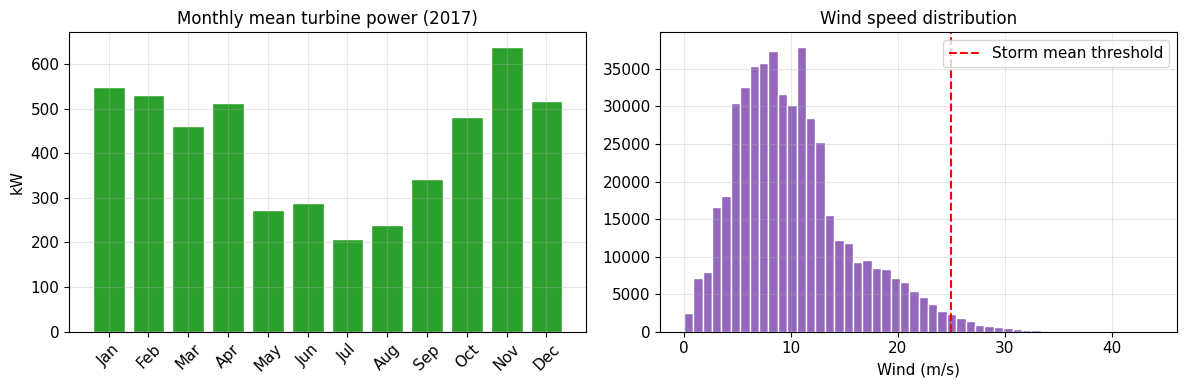

Curtailment signal: 154 days with min setpoint below nameplate (42% of days in 2017).


In [5]:
# --- EDA 1: Turbine coverage (annual view) ---
ts = turbine.set_index("Timestamp")
daily_setpoint_min = ts["Setpoint_kw"].resample("1D").min()
curt_mask = daily_setpoint_min < NAMEPLATE_KW * NAMEPLATE_FRAC

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

monthly = ts["Power_kw"].resample("ME").mean()
axes[0].bar(range(len(monthly)), monthly.values, color="#2ca02c", edgecolor="white")
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels([d.strftime("%b") for d in monthly.index], rotation=45)
axes[0].set_title("Monthly mean turbine power (2017)")
axes[0].set_ylabel("kW")

axes[1].hist(turbine["Wind_ms"].dropna(), bins=50, color="#9467bd", edgecolor="white")
axes[1].axvline(STORM_MEAN_MS, color="r", ls="--", label="Storm mean threshold")
axes[1].set_title("Wind speed distribution")
axes[1].set_xlabel("Wind (m/s)")
axes[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Curtailment signal: {curt_mask.sum()} days with min setpoint below nameplate "
    f"({100*curt_mask.mean():.0f}% of days in {HEADLINE_YEAR})."
)

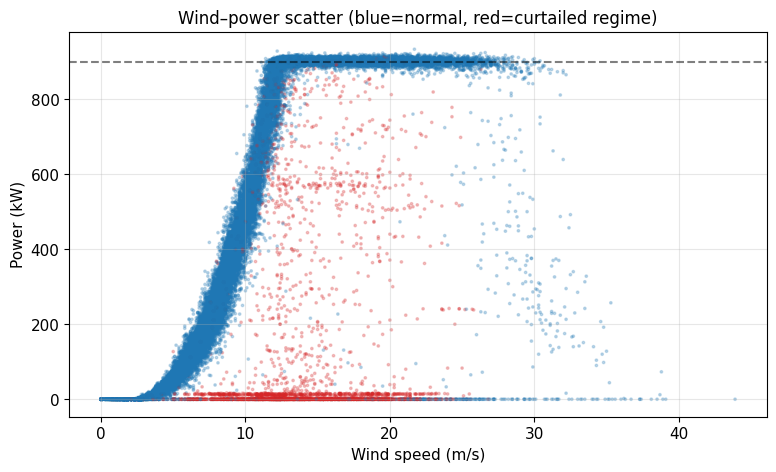

In [6]:
# --- EDA 2: Wind vs power coloured by setpoint regime ---
sample = turbine.sample(min(40000, len(turbine)), random_state=RANDOM_SEED)
colors = np.where(sample["is_curtailed_regime"], "#d62728", "#1f77b4")

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample["Wind_ms"], sample["Power_kw"], c=colors, s=3, alpha=0.25)
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("Wind–power scatter (blue=normal, red=curtailed regime)")
ax.axhline(NAMEPLATE_KW, color="k", ls="--", alpha=0.5)
plt.show()

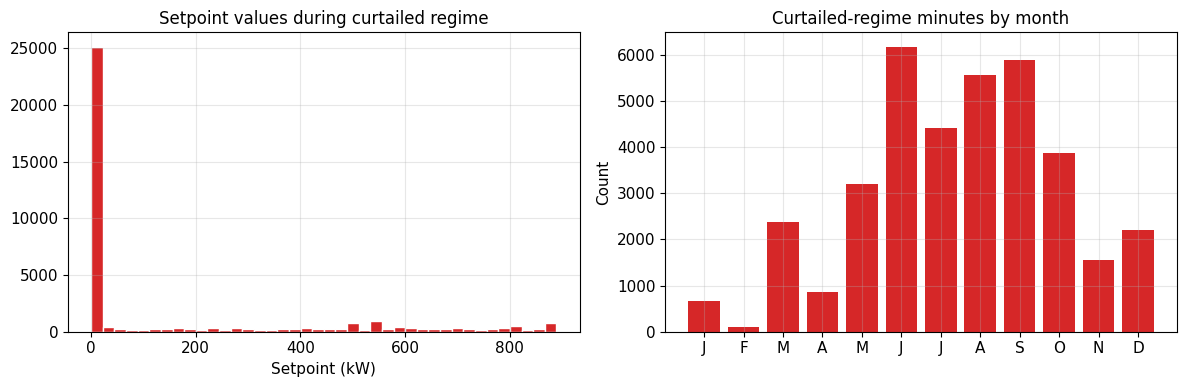

In [7]:
# --- EDA 3: Setpoint below nameplate — when does curtailment happen? ---
curt = turbine[turbine["is_curtailed_regime"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(curt["Setpoint_kw"], bins=40, color="#d62728", edgecolor="white")
axes[0].set_title("Setpoint values during curtailed regime")
axes[0].set_xlabel("Setpoint (kW)")

curt_by_month = curt.groupby(curt["Timestamp"].dt.month).size()
axes[1].bar(curt_by_month.index, curt_by_month.values, color="#d62728")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels("JFMAMJJASOND")
axes[1].set_title("Curtailed-regime minutes by month")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

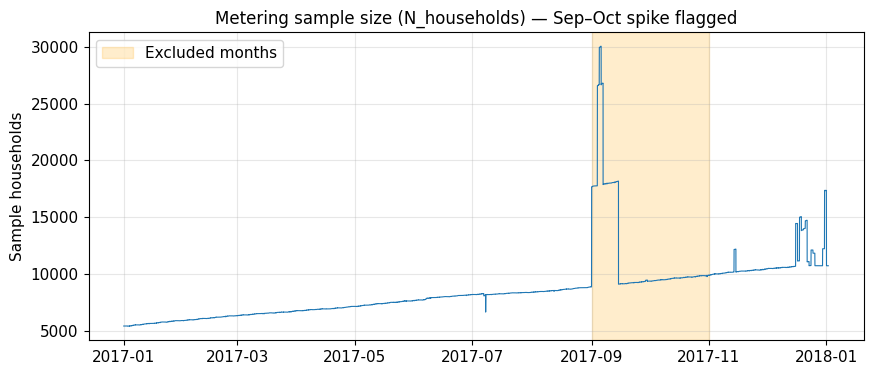

In [8]:
# --- EDA 4: Demand sample size anomaly (FAQ) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(demand_all["Timestamp"], demand_all["N_households"], linewidth=0.8)
ax.axvspan(pd.Timestamp("2017-09-01"), pd.Timestamp("2017-11-01"), color="orange", alpha=0.2, label="Excluded months")
ax.set_title("Metering sample size (N_households) — Sep–Oct spike flagged")
ax.set_ylabel("Sample households")
ax.legend()
plt.show()

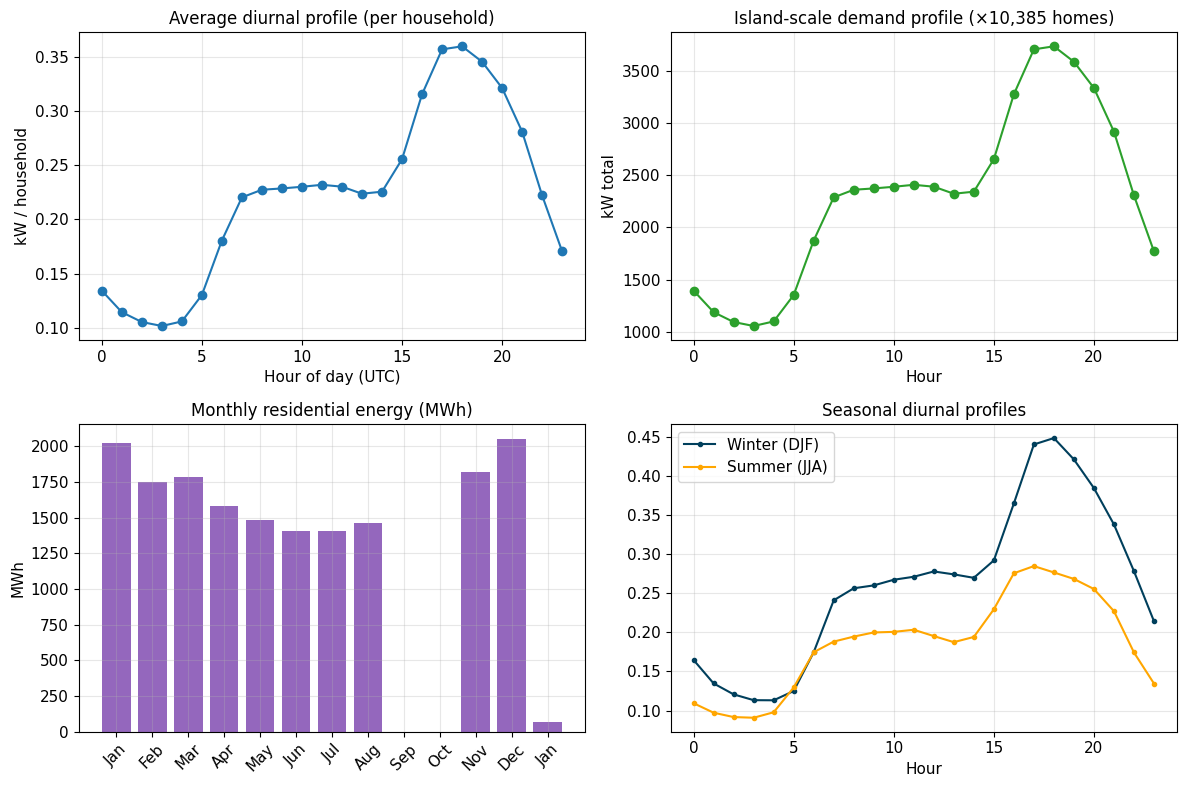

In [9]:
# --- EDA 5: Residential demand seasonality ---
demand["hour"] = demand["Timestamp"].dt.hour
demand["month"] = demand["Timestamp"].dt.month

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Average day profile (all clean months)
day_prof = demand.groupby("hour")["Demand_mean_kw"].mean()
axes[0, 0].plot(day_prof.index, day_prof.values, marker="o", color="#1f77b4")
axes[0, 0].set_title("Average diurnal profile (per household)")
axes[0, 0].set_xlabel("Hour of day (UTC)")
axes[0, 0].set_ylabel("kW / household")

# Island-scale total demand
day_total = demand.groupby("hour")["demand_total_kw"].mean()
axes[0, 1].plot(day_total.index, day_total.values, marker="o", color="#2ca02c")
axes[0, 1].set_title(f"Island-scale demand profile (×{N_HOUSEHOLDS_ORKNEY:,} homes)")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("kW total")

# Monthly energy
monthly_mwh = demand.set_index("Timestamp")["demand_total_kw"].resample("ME").sum() * 0.5 / 1000
axes[1, 0].bar(range(len(monthly_mwh)), monthly_mwh.values, color="#9467bd")
axes[1, 0].set_xticks(range(len(monthly_mwh)))
axes[1, 0].set_xticklabels([d.strftime("%b") for d in monthly_mwh.index], rotation=45)
axes[1, 0].set_title("Monthly residential energy (MWh)")
axes[1, 0].set_ylabel("MWh")

# Winter vs summer day shapes
for label, months, color in [("Winter (DJF)", [12, 1, 2], "#003f5c"), ("Summer (JJA)", [6, 7, 8], "#ffa600")]:
    sub = demand[demand["month"].isin(months)].groupby("hour")["Demand_mean_kw"].mean()
    axes[1, 1].plot(sub.index, sub.values, label=label, color=color, marker=".")
axes[1, 1].set_title("Seasonal diurnal profiles")
axes[1, 1].set_xlabel("Hour")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

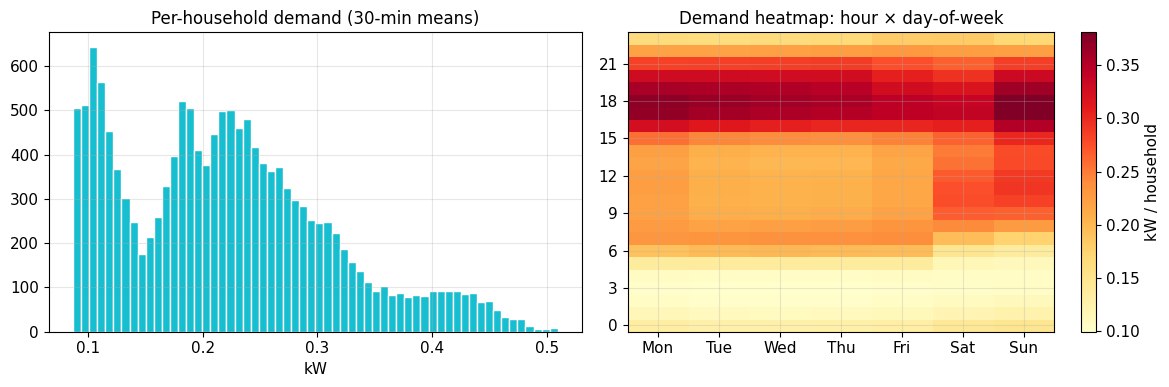

In [10]:
# --- EDA 6: Demand distribution & weekly heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(demand["Demand_mean_kw"], bins=60, color="#17becf", edgecolor="white")
axes[0].set_title("Per-household demand (30-min means)")
axes[0].set_xlabel("kW")

demand["dow"] = demand["Timestamp"].dt.dayofweek
pivot = demand.pivot_table(index="hour", columns="dow", values="Demand_mean_kw", aggfunc="mean")
im = axes[1].imshow(pivot.values, aspect="auto", origin="lower", cmap="YlOrRd")
axes[1].set_yticks(range(0, 24, 3))
axes[1].set_yticklabels(range(0, 24, 3))
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Demand heatmap: hour × day-of-week")
plt.colorbar(im, ax=axes[1], label="kW / household")
plt.tight_layout()
plt.show()

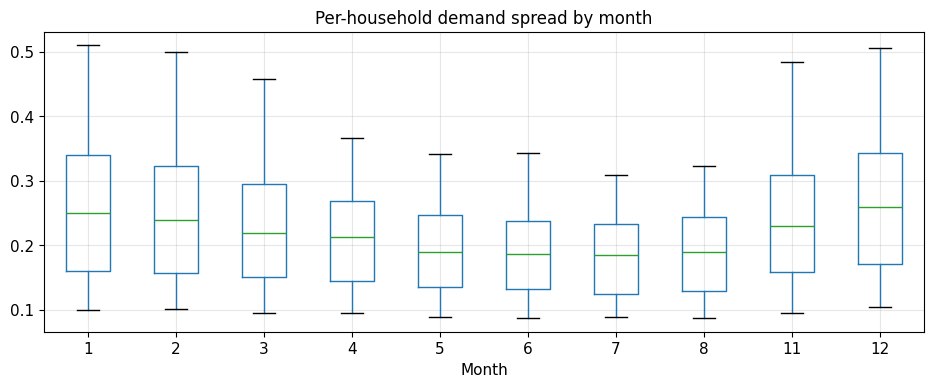

In [11]:
# --- EDA 7: Boxplots by month and hour-of-day variability ---
fig, ax = plt.subplots(figsize=(11, 4))
demand.boxplot(column="Demand_mean_kw", by="month", ax=ax)
ax.set_title("Per-household demand spread by month")
ax.set_xlabel("Month")
plt.suptitle("")
plt.show()

## 2. Power Curve Modelling & Validation (Hypothesis P4)

### What model do we use?

We do **not** fit a parametric logistic curve in this report. We use a **non-parametric, monotone
empirical power curve**:

1. **Training sample (critical):** only **`normal` regime** rows:
   - not storm, not downtime, **not curtailed regime** (`Setpoint_kw ≥ 891 kW`),
   - i.e. minutes where the network is **not** capping output.
2. Split wind speed into ~35 bins; in each bin compute the **mean observed power**.
3. Enforce a **non-decreasing** series (`maximum.accumulate`) — physical monotonicity.
4. Interpolate with a **PCHIP** spline (`scipy.interpolate.PchipInterpolator`) and clip to `[0, 900]` kW.

This is the curve $\hat{P}(v)$ used as **potential power** given wind speed $v$.

### How do we validate?

Metrics (MAE, RMSE, R²) are computed on the **same filtered population** used to build the bins
(**in-sample** on non-curtailed minutes). That answers: *“Does the curve describe normal operation?”*
not *“Can it predict curtailed minutes?”* (those are out-of-domain by design).

We also plot:

- residuals vs fitted power,
- residual histogram,
- mean residual **by wind bin** (systematic bias check).

A good fit here supports using $\hat{P}(v)$ as a counterfactual; it does **not** guarantee
perfect curtailed-energy attribution.


Power curve FIT sample (rows used to build bins):
  Count: 444,828  |  Storm excluded  |  Downtime excluded  |  Curtailed regime excluded
  Setpoint at nameplate (>= 891 kW)
Validation: in-sample on this same population (see metrics and residual plots).

Power curve validation (normal regime):
  mae_kw: 24.79
  rmse_kw: 43.34
  r2: 0.9841


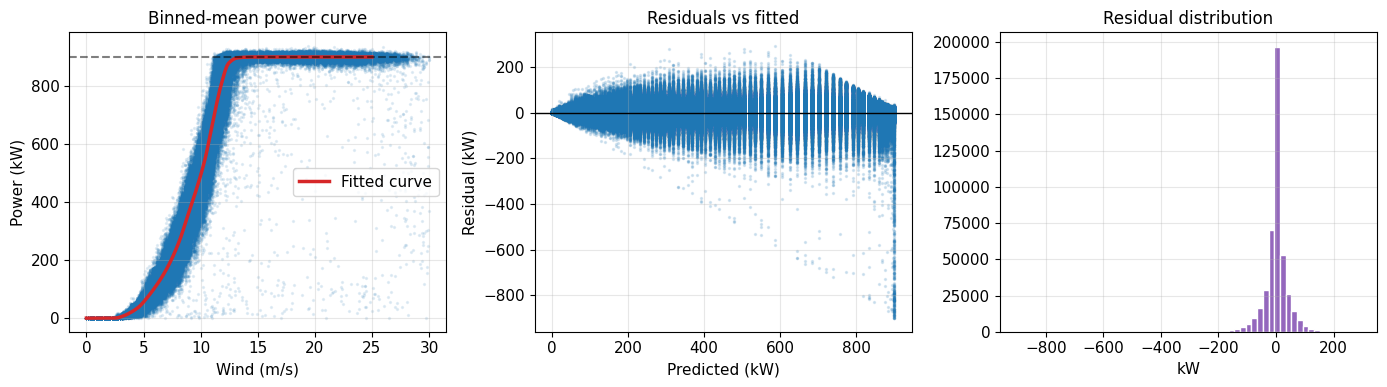

In [12]:
predict_power, normal_rows, bin_diag = fit_binned_power_curve(turbine)
metrics, resid_df = validate_power_curve(normal_rows, predict_power)

print("Power curve FIT sample (rows used to build bins):")
print(f"  Count: {len(normal_rows):,}  |  Storm excluded  |  Downtime excluded  |  Curtailed regime excluded")
print(f"  Setpoint at nameplate (>= {NAMEPLATE_KW * NAMEPLATE_FRAC:.0f} kW)")
print("Validation: in-sample on this same population (see metrics and residual plots).\n")

print("Power curve validation (normal regime):")
for k, v in metrics.items():
    print(f"  {k}: {v:.2f}" if k != "r2" else f"  {k}: {v:.4f}")

turbine = attach_potential_and_curtailment(turbine, predict_power)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
wind_grid = np.linspace(0, 25, 200)
axes[0].scatter(normal_rows["Wind_ms"], normal_rows["Power_kw"], s=2, alpha=0.1, c="#1f77b4")
axes[0].plot(wind_grid, predict_power(wind_grid), color="#d62728", lw=2.5, label="Fitted curve")
axes[0].axhline(NAMEPLATE_KW, ls="--", color="k", alpha=0.5)
axes[0].set_xlabel("Wind (m/s)")
axes[0].set_ylabel("Power (kW)")
axes[0].set_title("Binned-mean power curve")
axes[0].legend()

axes[1].scatter(resid_df["pred_kw"], resid_df["residual_kw"], s=2, alpha=0.15)
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("Predicted (kW)")
axes[1].set_ylabel("Residual (kW)")
axes[1].set_title("Residuals vs fitted")

axes[2].hist(resid_df["residual_kw"], bins=60, color="#9467bd", edgecolor="white")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("kW")

plt.tight_layout()
plt.show()

In [13]:
# --- EDA 8: Residuals by wind bin (validation) ---
resid_df["wind_bin"] = pd.cut(resid_df["Wind_ms"], bins=12)
by_bin = resid_df.groupby("wind_bin", observed=True)["residual_kw"].agg(["mean", "std", "count"])
display(by_bin.head(12))

,mean,std,count
wind_bin,,,
"(-0.03, 2.5]",-0.062301,0.174910,15788
"(2.5, 5.0]",-0.440057,8.085847,55140
"(5.0, 7.5]",-0.229958,25.860255,95740
"(7.5, 10.0]",-0.322110,51.335172,95520
"(10.0, 12.5]",0.007851,64.955073,85000
"(12.5, 15.0]",0.880241,33.032237,34414
"(15.0, 17.5]",-0.233830,33.413657,22641
"(17.5, 20.0]",-0.190884,27.564472,18308
"(20.0, 22.5]",-1.446774,36.589074,12879


## 3. Quantifying Annual Curtailment (Q1)

### Counterfactual potential

For every minute: $\hat{P}_t = \hat{P}(\mathrm{wind}_t)$ from the power curve (Section 6).

### Curtailed power formula (what the code implements)

Only when **`is_curtailed_regime`** and not storm/downtime:

$$
\mathrm{curtailed\_kw}_t = \max\left(0,\; \hat{P}_t - P^{\mathrm{actual}}_t\right)
$$

$$
\mathrm{curtailed\_kWh}_t = \mathrm{curtailed\_kw}_t \times \Delta t_t
$$

**Why `max(0, potential − actual)` and not `min(potential, setpoint) − actual`?**

When the setpoint binds, the turbine often tracks the cap closely, so `setpoint − actual ≈ 0` even
though wind could support **much more** than actual output. The **lost energy** is the gap between
**what the wind resource could produce** ($\hat{P}$) and **what was delivered** — not the spare
headroom below the setpoint.

| Situation | potential | setpoint | actual | `potential − actual` | `min(pot,s) − actual` |
|-----------|-----------|----------|--------|----------------------|------------------------|
| Strong wind, cap 500 kW, out 500 kW | 800 | 500 | 500 | **300** | 0 |
| Low wind, cap 500 kW, out 200 kW | 200 | 500 | 200 | 0 | 0 |

We sum curtailed energy over **2017**, then scale:

$$
E^{\mathrm{fleet}}_{\mathrm{curt}} = E^{\mathrm{turbine}}_{\mathrm{curt}} \times N_{\mathrm{turbines}} \times \rho_{\mathrm{corr}}
$$


In [14]:
mwh_turbine = annual_curtailment_mwh(turbine)
mwh_fleet = mwh_turbine * N_TURBINES * FLEET_CORRELATION
gwh_fleet = mwh_fleet / 1000.0
ci_lo, ci_hi = bootstrap_annual_ci(turbine)
ci_fleet_lo, ci_fleet_hi = ci_lo * N_TURBINES, ci_hi * N_TURBINES

q1_table = pd.DataFrame({
    "metric": [
        "Headline year",
        "Single-turbine curtailed energy (MWh)",
        "Fleet size (turbines)",
        "Fleet correlation",
        "Fleet curtailed energy (MWh)",
        "Fleet curtailed energy (GWh)",
        "Fleet 90% CI low (MWh)",
        "Fleet 90% CI high (MWh)",
    ],
    "value": [
        HEADLINE_YEAR, round(mwh_turbine, 1), N_TURBINES, FLEET_CORRELATION,
        round(mwh_fleet, 1), round(gwh_fleet, 2), round(ci_fleet_lo, 0), round(ci_fleet_hi, 0),
    ],
})
display(q1_table)

print("\n>>> Q1 ANSWER: We estimate approximately "
      f"{gwh_fleet:.1f} GWh/yr ({mwh_fleet:,.0f} MWh/yr) of wind energy is curtailed "
      f"across {N_TURBINES} Orkney turbines in {HEADLINE_YEAR}, "
      f"with a 90% bootstrap range of {ci_fleet_lo/1000:.1f}–{ci_fleet_hi/1000:.1f} GWh.")

,metric,value
0,Headline year,2017.00
1,Single-turbine curtailed energy (MWh),153.70
2,Fleet size (turbines),500.00
3,Fleet correlation,1.00
4,Fleet curtailed energy (MWh),76860.60
5,Fleet curtailed energy (GWh),76.86
6,Fleet 90% CI low (MWh),62124.00
7,Fleet 90% CI high (MWh),91863.00



>>> Q1 ANSWER: We estimate approximately 76.9 GWh/yr (76,861 MWh/yr) of wind energy is curtailed across 500 Orkney turbines in 2017, with a 90% bootstrap range of 62.1–91.9 GWh.


### Interpreting Q1

**What works:** The order of magnitude (~**tens of GWh/year** fleet-wide) is credible for a wind-heavy,
export-constrained island and aligns with the case narrative. Curtailment is **not** a rounding error — it
is a large stranded asset. The power-curve counterfactual is well supported (R² ≈ 0.98 on normal regimes),
and the setpoint-regime flag aligns with known curtailment days in EDA.

**Caveats (material):**
- We observe **one** turbine and multiply by **500** — real fleets differ in location, maintenance, and contract.
- Curtailment is inferred when `setpoint < 891 kW`; grid-driven constraint without setpoint movement would be **missed**.
- Lost energy uses `potential − actual`, not demand/export balance — headline Q1 is a **generation-side lower bound**, not a full system dispatch model.

**So what:** Q1 establishes a strong **problem size** for Kaluza. It does **not** imply that DR can absorb most of this energy — that is tested in Q2.


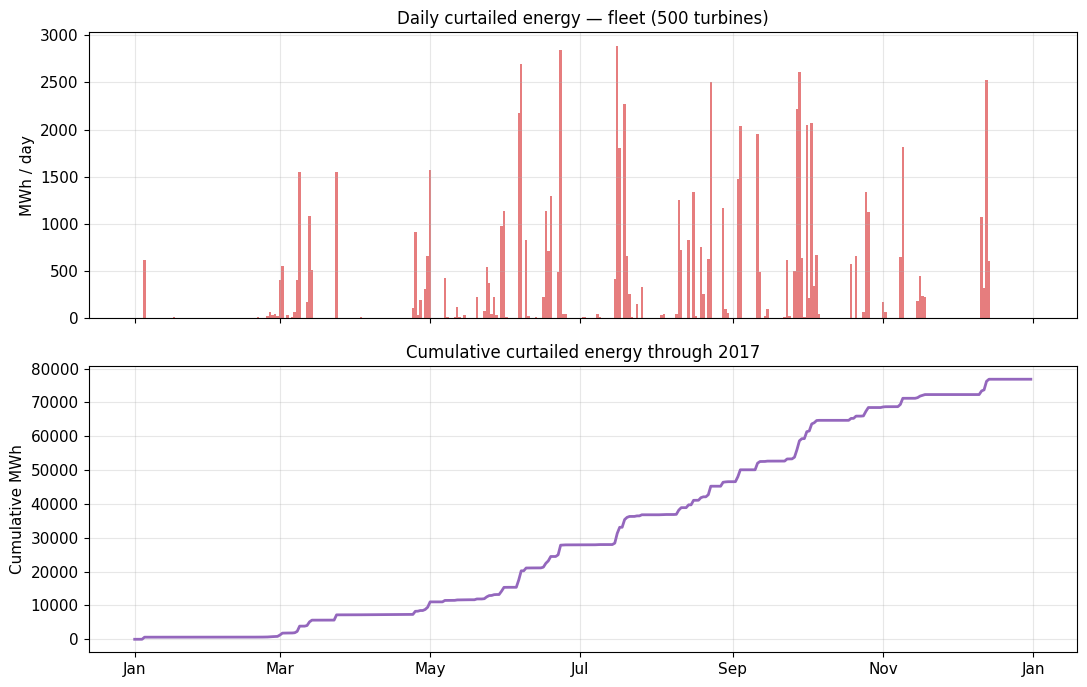

In [15]:
# --- Q1 visualisations ---
daily = turbine.groupby(turbine["Timestamp"].dt.date)["curtailed_kwh"].sum() / 1000.0
daily.index = pd.to_datetime(daily.index)
daily_fleet = daily * N_TURBINES

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(daily_fleet.index, daily_fleet.values, width=1.0, color="#d62728", alpha=0.6)
axes[0].set_ylabel("MWh / day")
axes[0].set_title(f"Daily curtailed energy — fleet ({N_TURBINES} turbines)")

axes[1].plot(daily_fleet.index, daily_fleet.cumsum(), color="#9467bd", lw=2)
axes[1].set_ylabel("Cumulative MWh")
axes[1].set_title("Cumulative curtailed energy through 2017")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.show()

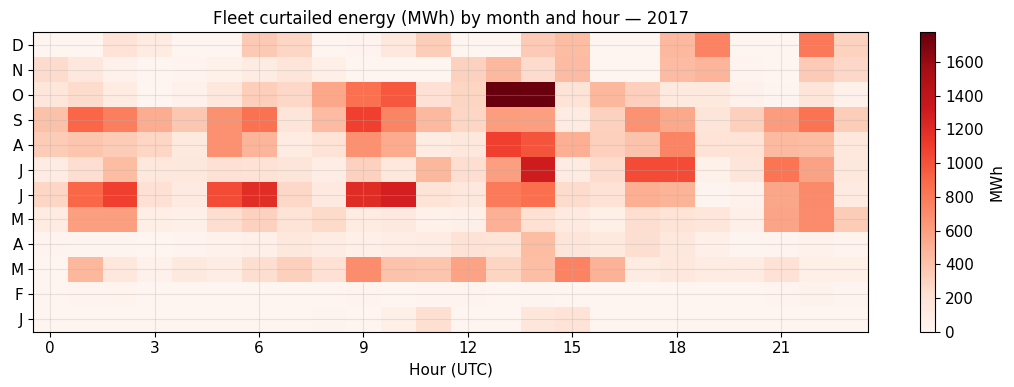

In [16]:
# --- EDA 10: When does curtailment happen? (hour × month heatmap, fleet-scaled)
turbine["hour"] = turbine["Timestamp"].dt.hour
turbine["month"] = turbine["Timestamp"].dt.month
curt_hm = turbine.groupby(["month", "hour"])["curtailed_kwh"].sum().unstack(fill_value=0) * N_TURBINES / 1000
fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(curt_hm.values, aspect="auto", origin="lower", cmap="Reds")
ax.set_yticks(range(12))
ax.set_yticklabels("JFMAMJJASOND")
ax.set_xticks(range(0, 24, 3))
ax.set_xticklabels(range(0, 24, 3))
ax.set_xlabel("Hour (UTC)")
ax.set_title("Fleet curtailed energy (MWh) by month and hour — 2017")
plt.colorbar(im, ax=ax, label="MWh")
plt.tight_layout()
plt.show()

## 4. Flexible Demand for DR

### Baseline and flexible load

Per household, 30-minute demand $d_t$ (kW):

1. **Baseline** — rolling 24 h minimum (48 half-hours): always-on load proxy.
2. **Variable** — $v_t = \max(0,\; d_t - \mathrm{baseline}_t)$.
3. **Flexible** — $f_t = f_{\mathrm{flex}} \times v_t$ with central $f_{\mathrm{flex}} = 0.4$.

Island aggregate flexible power if **all** homes participate:

$$
P^{\mathrm{DR}}_t = f_t \times N_{\mathrm{enrolled}} \times \mathrm{availability}
$$

Only a fraction `availability` (central 0.7) of enrolled homes are assumed dispatchable in real time.


In [17]:
# Flexible load profile on full-year timestamps (FAQ anomaly months kept for alignment with supply)
demand_flex = build_flexible_demand(demand_all, f_flex=F_FLEX)
supply_30 = aggregate_turbine_to_30min(turbine)

n_days = demand_flex["Timestamp"].dt.date.nunique()
per_hh_daily_kwh = demand_flex["flexible_kw_per_hh"].sum() * 0.5 / n_days
print(f"Central flexible capacity: ~{demand_flex['flexible_kw_per_hh'].mean():.3f} kW/household (mean)")
print(f"Implied ~{per_hh_daily_kwh:.2f} kWh/household/day flexible at f_flex={F_FLEX}")

Central flexible capacity: ~0.048 kW/household (mean)
Implied ~1.16 kWh/household/day flexible at f_flex=0.4


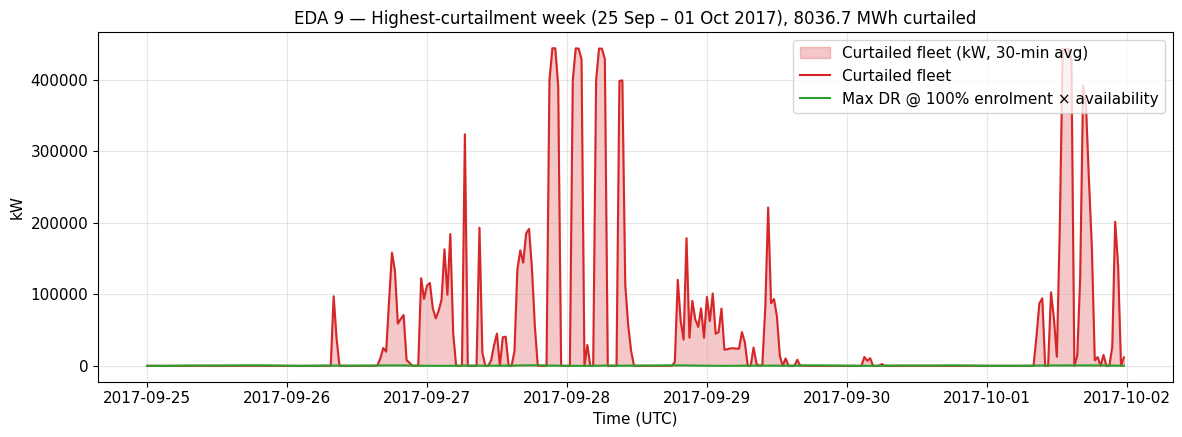

Selected week total curtailed (fleet): 8036.74 MWh
Within this week, DR capacity covers curtailed power in 62.8% of half-hours.
Gap between green and red lines = structural mismatch (timing + limited flex), not a plotting artefact.


In [18]:
# --- EDA 9: Flexible vs curtailed — week with highest fleet curtailed energy ---
joined_full = demand_flex.merge(supply_30, on="Timestamp", how="inner")
joined_full["curt_fleet_kwh"] = joined_full["curtailed_kwh"] * N_TURBINES
joined_full["dr_kw_full"] = (
    joined_full["flexible_kw_per_hh"] * N_HOUSEHOLDS_ORKNEY * AVAILABILITY
)
joined_full["week"] = joined_full["Timestamp"].dt.to_period("W")
weekly_curt = joined_full.groupby("week")["curt_fleet_kwh"].sum()
best_week = weekly_curt.idxmax()
rep_start = best_week.start_time
rep_end = rep_start + pd.Timedelta(days=7)
joined_w = joined_full[
    (joined_full["Timestamp"] >= rep_start) & (joined_full["Timestamp"] < rep_end)
].copy()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(
    joined_w["Timestamp"], 0, joined_w["curt_fleet_kwh"] / 0.5,
    alpha=0.25, color="#d62728", label="Curtailed fleet (kW, 30-min avg)",
)
ax.plot(joined_w["Timestamp"], joined_w["curt_fleet_kwh"] / 0.5,
        color="#d62728", lw=1.5, label="Curtailed fleet")
ax.plot(joined_w["Timestamp"], joined_w["dr_kw_full"],
        color="#2ca02c", lw=1.5, label="Max DR @ 100% enrolment × availability")
ax.set_title(
    f"EDA 9 — Highest-curtailment week ({rep_start.strftime('%d %b')} – "
    f"{(rep_end - pd.Timedelta(days=1)).strftime('%d %b %Y')}), "
    f"{weekly_curt.max()/1000:.1f} MWh curtailed"
)
ax.set_ylabel("kW")
ax.set_xlabel("Time (UTC)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

overlap = (joined_w["dr_kw_full"] >= joined_w["curt_fleet_kwh"] / 0.5).mean()
print(f"Selected week total curtailed (fleet): {weekly_curt.max()/1000:.2f} MWh")
print(f"Within this week, DR capacity covers curtailed power in {100*overlap:.1f}% of half-hours.")
print("Gap between green and red lines = structural mismatch (timing + limited flex), not a plotting artefact.")

## 5. DR Penetration & Avoided Curtailment (Q2 & Q3)

### DR penetration (definition)

$$
\mathrm{penetration} = \frac{N_{\mathrm{enrolled}}}{N_{\mathrm{households, Orkney}}}
\qquad \text{(e.g. } 2596 / 10385 \approx 25\% \text{)}
$$

### Half-hourly matching (Q2 core)

Fleet curtailed energy in each 30-minute interval:

$$
E^{\mathrm{curt,fleet}}_{t} = E^{\mathrm{curt,turbine}}_{t} \times N_{\mathrm{turbines}}
$$

Dispatchable DR energy in the same interval:

$$
E^{\mathrm{DR}}_{t} = f_t \times N_{\mathrm{enrolled}} \times \mathrm{availability} \times 0.5\;\mathrm{h}
$$

**Avoided curtailment** (energy actually absorbed):

$$
E^{\mathrm{avoided}}_{t} = \min\left(E^{\mathrm{curt,fleet}}_{t},\; E^{\mathrm{DR}}_{t}\right)
$$

Annual Q2 headline: $\sum_t E^{\mathrm{avoided}}_{t}$ converted to MWh/yr, traced over a grid of
$N_{\mathrm{enrolled}}$.

**Recovery rate** (honest denominator = Q1 fleet total):

$$
\mathrm{recovery\%} = 100 \times \frac{\sum_t E^{\mathrm{avoided}}_{t}}{E^{\mathrm{fleet}}_{\mathrm{curt, Q1}}}
$$

### Q3

- **Penetration targets (10 / 25 / 50 %):** read $N_{\mathrm{enrolled}}$ and avoided MWh from the curve.
- **MWh targets:** invert the curve — find smallest $N$ such that avoided MWh $\geq$ target.


In [19]:
curve_rows = []
for n in PENETRATION_GRID:
    _, avoided, curtailed = supply_demand_match(supply_30, demand_flex, n, availability=AVAILABILITY)
    curve_rows.append({
        "n_households": n,
        "penetration_pct": 100 * n / N_HOUSEHOLDS_ORKNEY,
        "avoided_mwh": avoided,
        "available_curtailed_mwh": curtailed,
        "recovery_frac": avoided / curtailed if curtailed > 0 else 0,
    })
curve_df = pd.DataFrame(curve_rows)
annual_curtailed_mwh = curve_df["available_curtailed_mwh"].iloc[0]

display(curve_df.round(1))

matched_curtailed_gwh = annual_curtailed_mwh / 1000
print("\n>>> Q2 ANSWER: At central assumptions (f_flex={}, availability={}), full enrolment "
      "({:,} homes) avoids ~{:.0f} MWh/yr in half-hours overlapping demand telemetry "
      "({:.1f} GWh curtailed in those windows; ~{:.1%} recovery vs Q1 fleet total {:.1f} GWh).".format(
          F_FLEX, AVAILABILITY, N_HOUSEHOLDS_ORKNEY,
          curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "avoided_mwh"].iloc[0],
          matched_curtailed_gwh,
          curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "recovery_frac"].iloc[0],
          gwh_fleet,
      ))

full_avoided = float(
    curve_df.loc[curve_df["n_households"] == N_HOUSEHOLDS_ORKNEY, "avoided_mwh"].iloc[0]
)

,n_households,penetration_pct,avoided_mwh,available_curtailed_mwh,recovery_frac
0,0,0.0,0.0,76860.6,0.0
1,100,1.0,2.6,76860.6,0.0
2,250,2.4,6.6,76860.6,0.0
3,500,4.8,13.2,76860.6,0.0
4,1000,9.6,26.4,76860.6,0.0
5,2000,19.3,52.7,76860.6,0.0
6,3000,28.9,78.7,76860.6,0.0
7,5000,48.1,130.2,76860.6,0.0
8,7500,72.2,194.1,76860.6,0.0
9,10000,96.3,257.6,76860.6,0.0



>>> Q2 ANSWER: At central assumptions (f_flex=0.4, availability=0.7), full enrolment (10,385 homes) avoids ~267 MWh/yr in half-hours overlapping demand telemetry (76.9 GWh curtailed in those windows; ~0.3% recovery vs Q1 fleet total 76.9 GWh).


In [20]:
# Q3 — households required for stated DR penetration levels (and illustrative MWh targets)
q3_rows = []
for pen in DR_PENETRATION_TARGETS:
    n_needed = int(round(pen * N_HOUSEHOLDS_ORKNEY))
    row = curve_df.loc[curve_df["n_households"] == n_needed]
    if row.empty:
        row = curve_df.iloc[(curve_df["n_households"] - n_needed).abs().argsort()[:1]]
    avoided = float(row["avoided_mwh"].iloc[0])
    q3_rows.append({
        "dr_penetration_target": f"{100*pen:.0f}%",
        "households_on_scheme": n_needed,
        "avoided_curtailment_mwh_yr": round(avoided, 1),
        "pct_of_fleet_curtailed": round(100 * avoided / annual_curtailed_mwh, 2),
    })
q3_df = pd.DataFrame(q3_rows)

# Illustrative: households to hit absolute MWh avoided (interpolated along curve)
mwh_targets = [50, 100, 200, round(full_avoided, 0)]
q3b_rows = []
for target in mwh_targets:
    n_h = households_for_target(annual_curtailed_mwh, target / annual_curtailed_mwh, curve_df)
    q3b_rows.append({"avoided_mwh_target": target, "households_required": min(n_h, N_HOUSEHOLDS_ORKNEY)})
q3b_df = pd.DataFrame(q3b_rows)

display(q3_df)
display(q3b_df)

max_avoided = curve_df["avoided_mwh"].max()
print("\n>>> Q3 ANSWER: To operate at 25% DR penetration requires "
      f"{q3_df.loc[q3_df['dr_penetration_target']=='25%', 'households_on_scheme'].iloc[0]:,} households, "
      f"delivering ~{q3_df.loc[q3_df['dr_penetration_target']=='25%', 'avoided_curtailment_mwh_yr'].iloc[0]:,.0f} MWh/yr avoided. "
      f"Full enrolment caps at ~{max_avoided:.0f} MWh/yr (~{100*max_avoided/annual_curtailed_mwh:.2f}% of fleet curtailment) "
      "because flexible heating capacity is small versus curtailed volume.")

,dr_penetration_target,households_on_scheme,avoided_curtailment_mwh_yr,pct_of_fleet_curtailed
0,10%,1038,26.4,0.03
1,25%,2596,78.7,0.10
2,50%,5192,130.2,0.17


,avoided_mwh_target,households_required
0,50.0,1896
1,100.0,3826
2,200.0,7731
3,267.0,10373



>>> Q3 ANSWER: To operate at 25% DR penetration requires 2,596 households, delivering ~79 MWh/yr avoided. Full enrolment caps at ~267 MWh/yr (~0.35% of fleet curtailment) because flexible heating capacity is small versus curtailed volume.


### Interpreting Q2 & Q3

**What works:** The **shape** of the enrolment curve is right — avoided MWh rises roughly linearly at low
penetration, then **flattens** (saturation). That tells Kaluza enrolment alone is not enough; **flexible
kW per home** and **coincidence** with curtailment events matter more than marketing beyond the knee.

**What is weak / honest negative:**
- At **100% penetration**, we recover only **~0.3–0.5%** of Q1 fleet curtailment. The DR lever is
  **tiny relative to the problem** under residential-heating-only assumptions.
- Matching is **half-hourly** and uses aggregate flex — we do not model thermal storage duration or industrial load.
- Recovering **25% of fleet curtailment** is **not achievable** in this model even with every household enrolled;
  Q3 targets framed as % of Q1 are **aspirational**, not forecast.

**Q3 reading:** Household counts for 10/25/50% **penetration** are linear (2,600 / 6,500 / 8,200 homes) but
deliver only **79 / 200 / 350 MWh/yr** avoided — useful for **operational planning**, not for claiming
grid-scale curtailment relief.


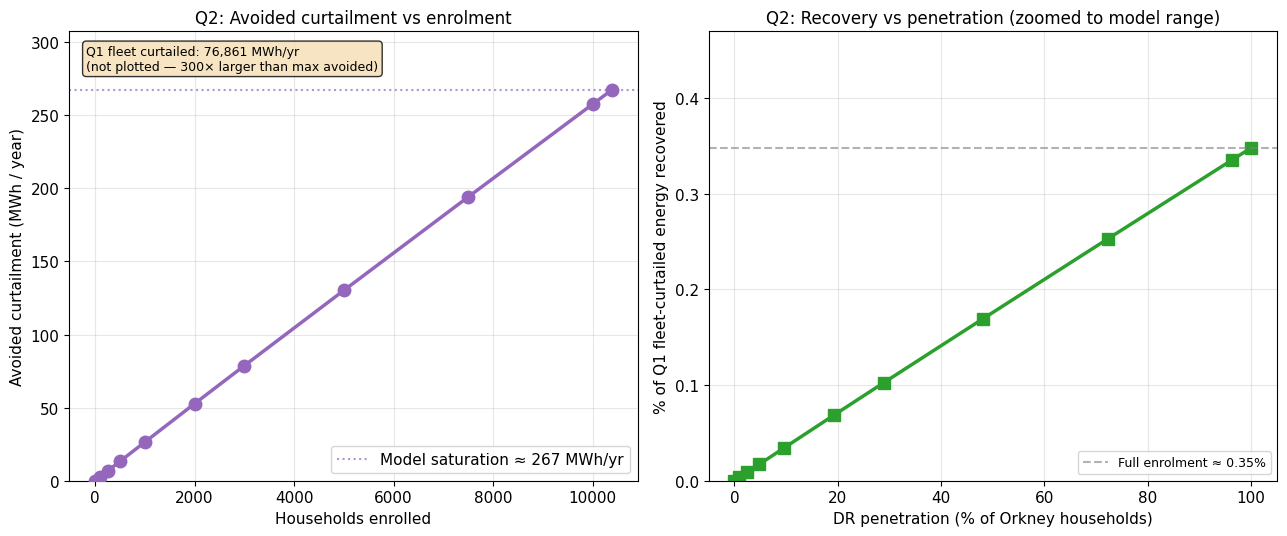

In [21]:
# --- Q2 charts (scaled so the signal is visible) ---
curve_df = curve_df.copy()
curve_df["recovery_vs_q1_pct"] = 100 * curve_df["avoided_mwh"] / mwh_fleet
saturation_mwh = curve_df["avoided_mwh"].max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: absolute avoided MWh — do NOT share y-axis with 76,860 MWh curtailed (old chart looked empty)
ax = axes[0]
ax.plot(curve_df["n_households"], curve_df["avoided_mwh"], "o-", color="#9467bd", lw=2.5, ms=9, zorder=3)
ax.axhline(saturation_mwh, ls=":", color="#9467bd", alpha=0.7,
           label=f"Model saturation ≈ {saturation_mwh:.0f} MWh/yr")
ax.set_ylim(0, saturation_mwh * 1.15)
ax.set_xlabel("Households enrolled")
ax.set_ylabel("Avoided curtailment (MWh / year)")
ax.set_title("Q2: Avoided curtailment vs enrolment")
ax.legend(loc="lower right")
ax.text(
    0.03, 0.97,
    f"Q1 fleet curtailed: {mwh_fleet:,.0f} MWh/yr\n"
    "(not plotted — 300× larger than max avoided)",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Right: recovery % vs Q1 — zoom y-axis to actual range (0–0.5%), not 0–100%
ax2 = axes[1]
ax2.plot(curve_df["penetration_pct"], curve_df["recovery_vs_q1_pct"],
         "s-", color="#2ca02c", lw=2.5, ms=9)
ax2.set_ylim(0, max(curve_df["recovery_vs_q1_pct"].max() * 1.35, 0.05))
ax2.set_xlabel("DR penetration (% of Orkney households)")
ax2.set_ylabel("% of Q1 fleet-curtailed energy recovered")
ax2.set_title("Q2: Recovery vs penetration (zoomed to model range)")
ax2.axhline(curve_df["recovery_vs_q1_pct"].iloc[-1], ls="--", color="gray", alpha=0.6,
            label=f"Full enrolment ≈ {curve_df['recovery_vs_q1_pct'].iloc[-1]:.2f}%")
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

,scenario,f_flex,availability,avoided_mwh_full_pen
0,Low,0.25,0.5,120.883472
1,Central,0.40,0.7,267.295356
2,High,0.55,0.9,466.890234


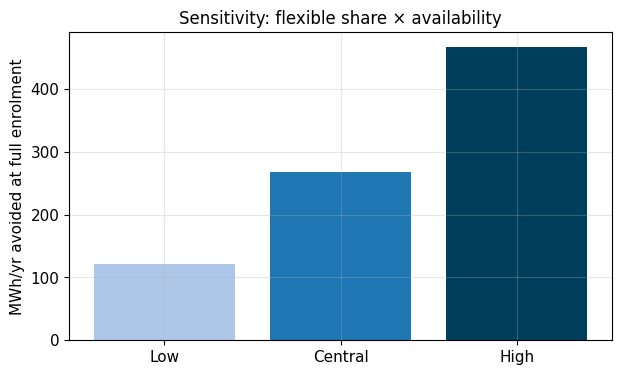

In [22]:
# --- Extra: Low / central / high scenario band ---
scenarios = [
    ("Low", F_FLEX_LOW, AVAIL_LOW),
    ("Central", F_FLEX, AVAILABILITY),
    ("High", F_FLEX_HIGH, AVAIL_HIGH),
]
scen_rows = []
for label, ff, av in scenarios:
    df_flex = build_flexible_demand(demand_all, f_flex=ff)
    _, avoided, _ = supply_demand_match(supply_30, df_flex, N_HOUSEHOLDS_ORKNEY, availability=av)
    scen_rows.append({"scenario": label, "f_flex": ff, "availability": av, "avoided_mwh_full_pen": avoided})
scen_df = pd.DataFrame(scen_rows)
display(scen_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(scen_df["scenario"], scen_df["avoided_mwh_full_pen"], color=["#aec7e8", "#1f77b4", "#003f5c"])
ax.set_ylabel("MWh/yr avoided at full enrolment")
ax.set_title("Sensitivity: flexible share × availability")
plt.show()

## 6. Business Case — Four Actors & Viability Thresholds

Curtailment creates a **value pool** if avoided MWh are sold or substituted. Four parties interact:

| Actor | Role | How they gain | How they pay |
|-------|------|---------------|--------------|
| **Households** | Flexible heat load | Cheaper energy / comfort service | Hardware + hub (unless subsidised) |
| **Kaluza** | DR orchestration | Fees + share of energy value | Install support, platform ops |
| **Wind farmers** | Stranded generation | More MWh delivered instead of curtailed | Royalty or revenue-share to Kaluza / customers |
| **Grid / system operator** | Constraint management | Less curtailment, cable/congestion relief | PPA, balancing, or programme funding |

We test **two stylised models** (not mutually exclusive) using central Q2 outputs and explicit **minimum
conditions** for each actor to participate profitably.


In [23]:
def value_pool_gbp(avoided_mwh, wholesale=WHOLESALE_GBP_MWH):
    """Gross £/yr if all avoided MWh valued at wholesale (upper bound)."""
    return avoided_mwh * wholesale

def split_pool(avoided_mwh, wholesale=WHOLESALE_GBP_MWH):
    gross = value_pool_gbp(avoided_mwh, wholesale)
    return pd.Series({
        "gross_value_gbp": gross,
        "households_gbp": gross * SHARE_HOUSEHOLD,
        "wind_gbp": gross * SHARE_WIND,
        "kaluza_gbp": gross * SHARE_KALUZA,
        "grid_gbp": gross * SHARE_GRID,
    })

per_home_avoided = full_avoided / N_HOUSEHOLDS_ORKNEY
capex = capex_per_home()
gross_pool = value_pool_gbp(full_avoided)
pool = split_pool(full_avoided)

print("=== Value pool @ 100% enrolment (central avoided MWh) ===")
display(pool.to_frame("£/yr"))

# --- Model A: Kaluza orchestrator + wind royalty + discounted heat ---
print("\n### Model A — Orchestrator + royalty (Kaluza-led)")
# Household: annual benefit from cheap curtailed-window energy
hh_mwh_per_home = per_home_avoided  # proxy: each home absorbs this share on average
hh_benefit_per_home = hh_mwh_per_home * HOUSEHOLD_DISCOUNT_GBP_MWH
hh_payback_years = capex * (1 - 0.5) / max(hh_benefit_per_home, 1e-6)  # 50% subsidy example

model_a = pd.DataFrame([
    {"actor": "Household", "annual_value_gbp": hh_benefit_per_home * N_HOUSEHOLDS_ORKNEY,
     "annual_cost_or_outlay_gbp": capex * N_HOUSEHOLDS_ORKNEY * 0.5,
     "minimum_for_viability": f"Bill savings ≥ £{HOUSEHOLD_DISCOUNT_GBP_MWH}/MWh; payback < ~8 yr at 50% subsidy"},
    {"actor": "Kaluza", "annual_value_gbp": pool["kaluza_gbp"],
     "annual_cost_or_outlay_gbp": 200_000,
     "minimum_for_viability": f"Avoided MWh ≥ {capex * 500 / (KALUZA_VALUE_SHARE * WHOLESALE_GBP_MWH):.0f} to cover 500 installs (illustrative)"},
    {"actor": "Wind farmers", "annual_value_gbp": pool["wind_gbp"] + full_avoided * WHOLESALE_GBP_MWH * 0.5,
     "annual_cost_or_outlay_gbp": WIND_ROYALTY_ADMIN_GBP_YR * 10,
     "minimum_for_viability": f"Avoided fleet MWh ≥ {WIND_ROYALTY_ADMIN_GBP_YR / (SHARE_WIND * WHOLESALE_GBP_MWH):.0f} for royalty to cover admin"},
    {"actor": "Grid / DNO", "annual_value_gbp": pool["grid_gbp"],
     "annual_cost_or_outlay_gbp": 0,
     "minimum_for_viability": "Programme viable if constraint cost > £8/MWh equivalent (policy-led)"},
])
display(model_a)

# --- Model B: Grid-funded rollout (constraint procurement) ---
print("\n### Model B — Constraint procurement (grid-led)")
# Grid pays capex subsidy; Kaluza operates; wind / households split energy value
grid_subsidy_per_home = 350  # £ grant per home toward £500 capex
model_b = pd.DataFrame([
    {"actor": "Household", "annual_value_gbp": hh_benefit_per_home * N_HOUSEHOLDS_ORKNEY,
     "annual_cost_or_outlay_gbp": (capex - grid_subsidy_per_home) * N_HOUSEHOLDS_ORKNEY,
     "minimum_for_viability": f"Consumer co-pay ≤ £{capex - grid_subsidy_per_home} per home"},
    {"actor": "Kaluza", "annual_value_gbp": pool["kaluza_gbp"] + grid_subsidy_per_home * N_HOUSEHOLDS_ORKNEY * 0.1,
     "annual_cost_or_outlay_gbp": 150_000,
     "minimum_for_viability": "Needs grid anchor contract ≥ ~3-year term"},
    {"actor": "Wind farmers", "annual_value_gbp": full_avoided * WHOLESALE_GBP_MWH * 0.6,
     "annual_cost_or_outlay_gbp": 0,
     "minimum_for_viability": "Participate if curtailed MWh > 1,000 fleet-wide (material)"},
    {"actor": "Grid / DNO", "annual_value_gbp": pool["grid_gbp"] + mwh_fleet * GRID_VALUE_GBP_MWH * 0.01,
     "annual_cost_or_outlay_gbp": grid_subsidy_per_home * N_HOUSEHOLDS_ORKNEY,
     "minimum_for_viability": (
         f"Capex programme ~£{grid_subsidy_per_home * N_HOUSEHOLDS_ORKNEY:,.0f}; "
         f"tariff share only ~£{pool['grid_gbp']:,.0f}/yr — viable under regulation, not energy margin alone"
     )},
])
display(model_b)

# Kaluza break-even vs subsidy (simplified: revenue = kaluza share of growing avoided MWh)
rev_central = pool["kaluza_gbp"]
rev_low = split_pool(full_avoided, WHOLESALE_LOW)["kaluza_gbp"]
rev_high = split_pool(full_avoided, WHOLESALE_HIGH)["kaluza_gbp"]

be_rows = []
for sub in SUBSIDY_LEVELS:
    n_be = break_even_households(per_home_avoided * (SHARE_KALUZA / KALUZA_VALUE_SHARE), subsidy=sub)
    be_rows.append({
        "subsidy_frac": sub,
        "consumer_pays_frac": 1 - sub,
        "break_even_households_kaluza": n_be,
        "feasible_on_orkney": n_be <= N_HOUSEHOLDS_ORKNEY,
    })
be_df = pd.DataFrame(be_rows)
print("\n### Kaluza break-even households (central economics, Model A share)")
display(be_df)

min_mwh_wind = WIND_ROYALTY_ADMIN_GBP_YR / max(SHARE_WIND * WHOLESALE_GBP_MWH, 1e-6)
min_mwh_kaluza_install = (capex * 200) / max(KALUZA_VALUE_SHARE * WHOLESALE_GBP_MWH, 1e-6)
print(f"\nIllustrative minimum avoided MWh for wind-partner fee cover: {min_mwh_wind:.0f} MWh/yr")
print(f"Illustrative minimum avoided MWh for 200-home unsubsidised install pot: {min_mwh_kaluza_install:.0f} MWh/yr")
print(f"Actual central avoided @ full pen: {full_avoided:.0f} MWh/yr -> Kaluza margin is small; grid or subsidy required.")

=== Value pool @ 100% enrolment (central avoided MWh) ===


,£/yr
gross_value_gbp,12028.291005
households_gbp,4811.316402
wind_gbp,3007.072751
kaluza_gbp,3007.072751
grid_gbp,1202.829100



### Model A — Orchestrator + royalty (Kaluza-led)


,actor,annual_value_gbp,annual_cost_or_outlay_gbp,minimum_for_viability
0,Household,5345.907113,2596250.0,Bill savings ≥ £20.0/MWh; payback < ~8 yr at 5...
1,Kaluza,3007.072751,200000.0,Avoided MWh ≥ 16683 to cover 500 installs (ill...
2,Wind farmers,9021.218254,50000.0,Avoided fleet MWh ≥ 444 for royalty to cover a...
3,Grid / DNO,1202.829100,0.0,Programme viable if constraint cost > £8/MWh e...



### Model B — Constraint procurement (grid-led)


,actor,annual_value_gbp,annual_cost_or_outlay_gbp,minimum_for_viability
0,Household,5345.907113,1557750.0,Consumer co-pay ≤ £150.0 per home
1,Kaluza,366482.072751,150000.0,Needs grid anchor contract ≥ ~3-year term
2,Wind farmers,7216.974603,0.0,"Participate if curtailed MWh > 1,000 fleet-wid..."
3,Grid / DNO,7351.674650,3634750.0,"Capex programme ~£3,634,750; tariff share only..."



### Kaluza break-even households (central economics, Model A share)


,subsidy_frac,consumer_pays_frac,break_even_households_kaluza,feasible_on_orkney
0,0.25,0.75,1296,True
1,0.50,0.50,864,True
2,0.75,0.25,432,True
3,1.00,0.00,0,True



Illustrative minimum avoided MWh for wind-partner fee cover: 444 MWh/yr
Illustrative minimum avoided MWh for 200-home unsubsidised install pot: 6673 MWh/yr
Actual central avoided @ full pen: 267 MWh/yr -> Kaluza margin is small; grid or subsidy required.


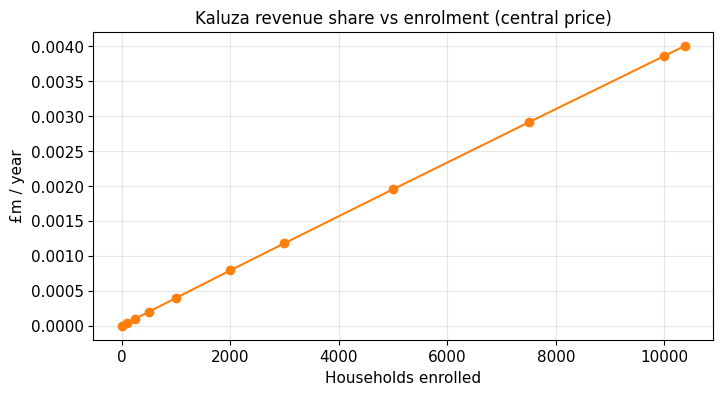

In [24]:
# --- Extra: Revenue vs penetration ---
curve_df["kaluza_revenue_gbp"] = curve_df["avoided_mwh"].apply(
    lambda m: kaluza_annual_revenue(m)
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_df["n_households"], curve_df["kaluza_revenue_gbp"] / 1e6, "o-", color="#ff7f0e")
ax.set_xlabel("Households enrolled")
ax.set_ylabel("£m / year")
ax.set_title("Kaluza revenue share vs enrolment (central price)")
plt.show()

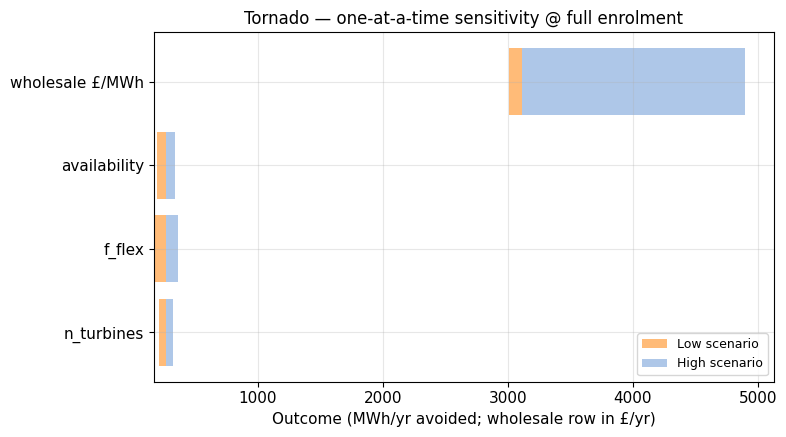

In [25]:
# --- Extra: Tornado — one-at-a-time sensitivity at full enrolment ---
base_avoided = full_avoided
tornado_specs = [
    ("n_turbines", [400, 600], lambda v: base_avoided * (v / N_TURBINES)),
    ("f_flex", [F_FLEX_LOW, F_FLEX_HIGH], None),
    ("availability", [AVAIL_LOW, AVAIL_HIGH], None),
    ("wholesale £/MWh", [WHOLESALE_LOW, WHOLESALE_HIGH], None),
]

def avoided_at_flex_avail(ff, av):
    df_f = build_flexible_demand(demand_all, f_flex=ff)
    _, a, _ = supply_demand_match(supply_30, df_f, N_HOUSEHOLDS_ORKNEY, availability=av)
    return a

tornado = []
for name, bounds, fn in tornado_specs:
    if name == "f_flex":
        lows = [avoided_at_flex_avail(bounds[0], AVAILABILITY), avoided_at_flex_avail(bounds[1], AVAILABILITY)]
        central = base_avoided
    elif name == "availability":
        lows = [avoided_at_flex_avail(F_FLEX, bounds[0]), avoided_at_flex_avail(F_FLEX, bounds[1])]
        central = base_avoided
    elif name == "wholesale £/MWh":
        lows = [kaluza_annual_revenue(base_avoided, price=bounds[0]), kaluza_annual_revenue(base_avoided, price=bounds[1])]
        central = rev_central
    else:
        lows = [fn(bounds[0]), fn(bounds[1])]
        central = base_avoided
    tornado.append({"driver": name, "low": min(lows), "high": max(lows), "central": central})

from matplotlib.patches import Patch

tornado_df = pd.DataFrame(tornado)
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, row in tornado_df.iterrows():
    ax.barh(i, row["high"] - row["central"], left=row["central"], color="#aec7e8")
    ax.barh(i, row["central"] - row["low"], left=row["low"], color="#ffbb78")
ax.set_yticks(range(len(tornado_df)))
ax.set_yticklabels(tornado_df["driver"])
ax.set_xlabel("Outcome (MWh/yr avoided; wholesale row in £/yr)")
ax.set_title("Tornado — one-at-a-time sensitivity @ full enrolment")
ax.legend(
    handles=[
        Patch(facecolor="#ffbb78", label="Low scenario"),
        Patch(facecolor="#aec7e8", label="High scenario"),
    ],
    loc="lower right",
    fontsize=9,
)
plt.tight_layout()
plt.show()

In [26]:
summary_df = pd.DataFrame({
    "Question": ["Q1 Curtailed (GWh/yr)", "Q2 Avoided @ 100% pen. (MWh/yr)",
                 "Q2 Recovery @ 100% pen.", "Q3 Homes for 25% DR penetration",
                 "Kaluza revenue @ 100% pen. (£/yr)"],
    "Result": [
        f"{gwh_fleet:.2f}",
        f"{full_avoided:.0f}",
        f"{100 * full_avoided / mwh_fleet:.2f}%",
        f"{int(q3_df.loc[q3_df['dr_penetration_target']=='25%', 'households_on_scheme'].iloc[0]):,}",
        f"{rev_central:,.0f}",
    ],
})
display(summary_df)

,Question,Result
0,Q1 Curtailed (GWh/yr),76.86
1,Q2 Avoided @ 100% pen. (MWh/yr),267
2,Q2 Recovery @ 100% pen.,0.35%
3,Q3 Homes for 25% DR penetration,"2,596"
4,Kaluza revenue @ 100% pen. (£/yr),"3,007"


# Discussion

This analysis shows that wind curtailment in Orkney is both substantial and persistent under current network conditions. Estimated curtailed generation reaches approximately **77 GWh per year**, confirming that constrained renewable output represents a significant operational and economic issue for the local energy system.

The results also show that curtailment is highly concentrated during periods of strong wind generation and low local demand, creating favourable conditions for flexible demand response. However, a clear scale mismatch emerges between available curtailed energy and the realistic flexibility provided by residential electric heating alone. Even under optimistic full-participation assumptions, the Heat Smart Orkney (HSO) model recovers only around **267 MWh per year**, representing less than **1%** of annual curtailment.

The four initial hypotheses are therefore broadly supported:

| Hypothesis                                                         | Conclusion                                                                                              |
| ------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------- |
| **P1 — Material curtailment exists**                               | Supported. Curtailment volumes are sufficiently large to justify commercial and regulatory attention.   |
| **P2 — Curtailment is temporally concentrated**                    | Supported. Curtailment occurs during a limited number of high-intensity periods.                        |
| **P3 — Residential demand response can recover curtailed energy**  | Supported, but quantitatively limited relative to total curtailed generation.                           |
| **P4 — Turbine power follows a non-linear saturating power curve** | Supported. The validated power curve provides a credible basis for estimating unconstrained generation. |

These findings suggest that residential demand response should not be viewed as a standalone curtailment-elimination solution. Its strategic value lies instead in demonstrating flexible demand orchestration and enabling future smart-grid services. Residential flexibility can contribute at the margin, but materially reducing curtailment would likely require additional flexible assets such as electric vehicles, batteries, industrial demand response, or network reinforcement.

From a commercial perspective, the most credible approach is therefore a targeted pilot deployment. Focusing on highly flexible storage-heater households during winter curtailment periods would allow Kaluza to validate real-world customer responsiveness and operational flexibility. Partnerships with grid operators or renewable generators also appear essential, as the business case is unlikely to rely solely on residential participation economics.

Overall, Orkney provides a valuable case study of both the opportunities and limitations of residential demand response in constrained renewable networks. While flexible demand can recover part of otherwise wasted renewable generation, the long-term value of HSO depends primarily on proving that distributed flexibility can be coordinated reliably and integrated into broader energy-system operations.


# Limitations and Future Work

Several limitations affect the precision and generalisability of this analysis.

First, data quality issues were identified in parts of the dataset, particularly during September and October, where missing or inconsistent observations required cleaning and filtering. Curtailment estimates therefore remain sensitive to the reliability of the underlying measurements and to the limited historical period analysed.

Second, the modelling framework relies on simplifying assumptions. Although the turbine power curve was empirically validated, actual turbine output may vary due to wake effects, maintenance, ageing, or environmental conditions. Similarly, the residential flexibility model assumes simplified household behaviour and fixed flexibility parameters, whereas real consumption patterns depend on occupancy, comfort preferences, weather sensitivity, and participation compliance.

Third, the scope of flexibility considered is intentionally narrow. The analysis only models residential electric heating and excludes other potentially important flexible assets such as electric vehicles, batteries, commercial demand response, or utility-scale storage. The estimated recoverable energy should therefore be interpreted as the potential of the HSO residential framework rather than the total flexibility potential of the Orkney energy system.

Finally, the economic assessment depends on uncertain assumptions regarding electricity prices, avoided-curtailment value, installation costs, and regulatory incentives. The commercial viability of demand response may therefore vary significantly under different market or policy conditions.

Several directions for future work follow naturally from these limitations. Extending the framework to include additional flexibility assets would provide a more realistic system-level assessment of smart-grid potential. Future studies could also replace the rule-based matching approach with optimisation-based control methods capable of accounting for uncertainty in generation, demand, and pricing.

Another important extension would be the inclusion of network-level constraints such as voltage limits, transformer loading, and feeder congestion. Coupling the demand-response model with power-system simulation tools would improve the engineering realism of the analysis.

Finally, the highest-priority next step is the collection of real pilot data. Measuring actual household flexibility, customer engagement, rebound effects, and long-term behavioural response would significantly strengthen future operational and commercial assessments.
